In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')

X = pd.read_csv('../data/processed/X_features.csv')
y_household = pd.read_csv('../data/processed/y_household.csv').squeeze()
y_logistic  = pd.read_csv('../data/processed/y_logistic.csv').squeeze()
y_facility  = pd.read_csv('../data/processed/y_facility.csv').squeeze()

print(f'Feature matrix: {X.shape}')
print(f'Household target: {y_household.value_counts().to_dict()}')

Feature matrix: (724115, 56)
Household target: {0: 527477, 1: 196638}


In [2]:
from src.preprocessing.split_scale import split_and_scale

X_tr_hh, X_te_hh, y_tr_hh, y_te_hh, _ = split_and_scale(
    pd.concat([X, y_household], axis=1), 'target_household')
X_tr_lg, X_te_lg, y_tr_lg, y_te_lg, _ = split_and_scale(
    pd.concat([X, y_logistic],  axis=1), 'target_logistic')
X_tr_fc, X_te_fc, y_tr_fc, y_te_fc, _ = split_and_scale(
    pd.concat([X, y_facility],  axis=1), 'target_facility')

target_household - Train: 579292 rows | Test: 144823 rows
target_logistic - Train: 579292 rows | Test: 144823 rows
target_facility - Train: 579292 rows | Test: 144823 rows


In [3]:
from src.models.decision_tree import train_decision_tree

dt_hh = train_decision_tree(X_tr_hh, y_tr_hh, X.columns.tolist(), 'household')
dt_lg = train_decision_tree(X_tr_lg, y_tr_lg, X.columns.tolist(), 'logistic')
dt_fc = train_decision_tree(X_tr_fc, y_tr_fc, X.columns.tolist(), 'facility')

Best params for household: {'max_depth': 5, 'min_samples_leaf': 10}

--- Decision Rules for household barrier ---
|--- v190_poorest <= 0.72
|   |--- v190_poorer <= 0.67
|   |   |--- v190_richest <= 0.88
|   |   |   |--- v190_richer <= 0.78
|   |   |   |   |--- media_exposure_index <= -0.94
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- media_exposure_index >  -0.94
|   |   |   |   |   |--- class: 0
|   |   |   |--- v190_richer >  0.78
|   |   |   |   |--- media_exposure_index <= -0.94
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- media_exposure_index >  -0.94
|   |   |   |   |   |--- class: 0
|   |   |--- v190_richest >  0.88
|   |   |   |--- media_exposure_index <= -0.25
|   |   |   |   |--- v130_hindu <= -0.59
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- v130_hindu >  -0.59
|   |   |   |   |   |--- class: 0
|   |   |   |--- media_exposure_index >  -0.25
|   |   |   |   |--- v157_not at all <= -0.39
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- v157

KeyboardInterrupt: 


=== Decision Tree | household barrier ===
  Model       : Decision Tree
  Target      : household
  Accuracy    : 0.8028
  ROC-AUC     : 0.833
  Precision   : 0.8525
  Recall      : 0.7324
  F1-Score    : 0.7879
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        71
           1       0.85      0.73      0.79        71

    accuracy                           0.80       142
   macro avg       0.81      0.80      0.80       142
weighted avg       0.81      0.80      0.80       142



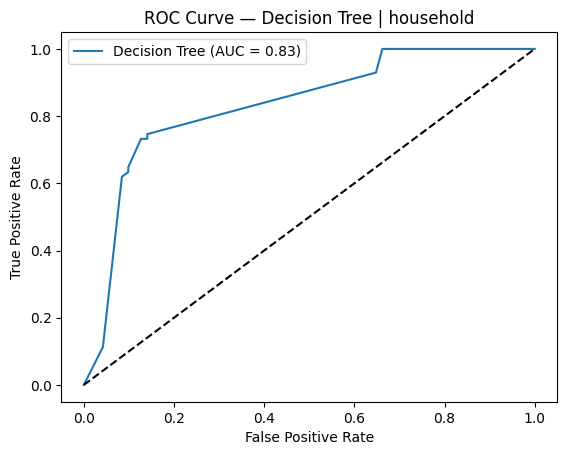

Saved: outputs/stage1_results/roc_curves/Decision Tree_household.png


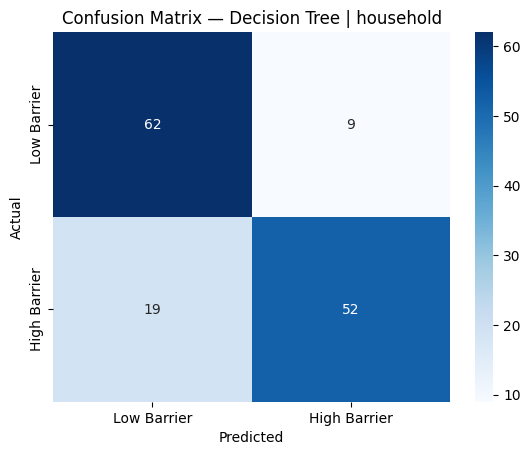

Saved: outputs/stage1_results/confusion_matrices/Decision Tree_household.png

=== Decision Tree | logistic barrier ===
  Model       : Decision Tree
  Target      : logistic
  Accuracy    : 0.7324
  ROC-AUC     : 0.8446
  Precision   : 0.6854
  Recall      : 0.8592
  F1-Score    : 0.7625
              precision    recall  f1-score   support

           0       0.81      0.61      0.69        71
           1       0.69      0.86      0.76        71

    accuracy                           0.73       142
   macro avg       0.75      0.73      0.73       142
weighted avg       0.75      0.73      0.73       142



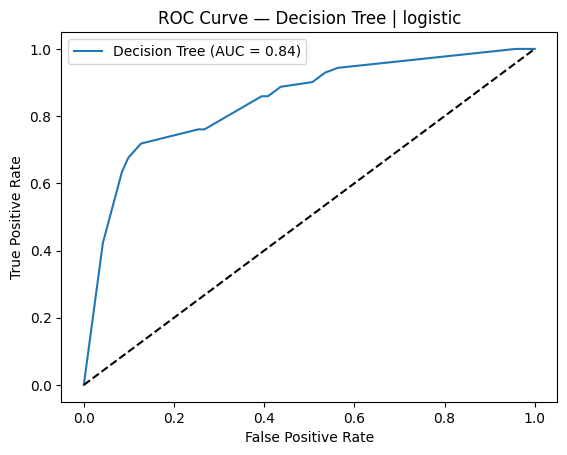

Saved: outputs/stage1_results/roc_curves/Decision Tree_logistic.png


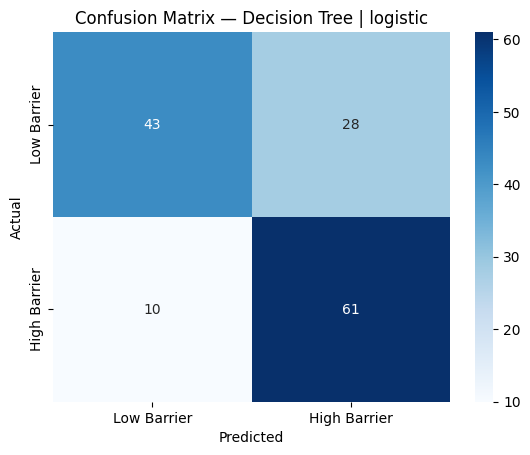

Saved: outputs/stage1_results/confusion_matrices/Decision Tree_logistic.png

=== Decision Tree | facility barrier ===
  Model       : Decision Tree
  Target      : facility
  Accuracy    : 0.7254
  ROC-AUC     : 0.775
  Precision   : 0.7162
  Recall      : 0.7465
  F1-Score    : 0.731
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        71
           1       0.72      0.75      0.73        71

    accuracy                           0.73       142
   macro avg       0.73      0.73      0.73       142
weighted avg       0.73      0.73      0.73       142



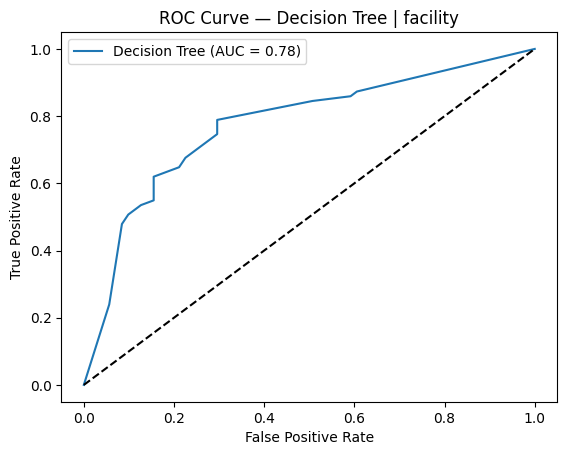

Saved: outputs/stage1_results/roc_curves/Decision Tree_facility.png


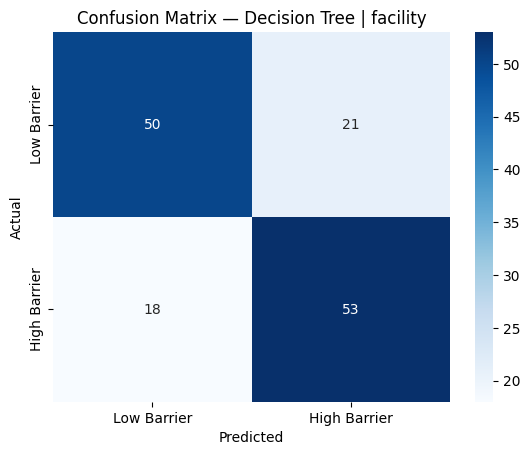

Saved: outputs/stage1_results/confusion_matrices/Decision Tree_facility.png


In [ ]:
from src.evaluation.metrics import evaluate_model
from src.evaluation.visualise import plot_roc_curve, plot_confusion_matrix

results = []
for model, X_te, y_te, target in [
    (dt_hh, X_te_hh, y_te_hh, 'household'),
    (dt_lg, X_te_lg, y_te_lg, 'logistic'),
    (dt_fc, X_te_fc, y_te_fc, 'facility')
]:
    r = evaluate_model(model, X_te, y_te, 'Decision Tree', target)
    results.append(r)
    plot_roc_curve(model, X_te, y_te, 'Decision Tree', target)
    plot_confusion_matrix(model, X_te, y_te, 'Decision Tree', target)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, y, target in [
    (dt_hh, y_household, 'household'),
    (dt_lg, y_logistic,  'logistic'),
    (dt_fc, y_facility,  'facility')
]:
    scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc')
    print(f'DT | {target} | CV AUC: {scores.mean():.4f} +/- {scores.std():.4f}')

DT | household | CV AUC: 0.8258 +/- 0.0278
DT | logistic | CV AUC: 0.8477 +/- 0.0268
DT | facility | CV AUC: 0.8065 +/- 0.0311


In [ ]:
import pandas as pd
import os

# Create the folder if it doesn't exist
os.makedirs('../outputs/stage1_results', exist_ok=True)

results_df = pd.DataFrame(results)
results_df.to_csv('../outputs/stage1_results/decision_tree_results.csv', index=False)
print('Results saved!')
print(results_df)

Results saved!
           Model     Target  Accuracy  ROC-AUC  Precision  Recall  F1-Score
0  Decision Tree  household    0.8028   0.8330     0.8525  0.7324    0.7879
1  Decision Tree   logistic    0.7324   0.8446     0.6854  0.8592    0.7625
2  Decision Tree   facility    0.7254   0.7750     0.7162  0.7465    0.7310
